In this notebook, we train and evaluate an NL-LFR model on all combined amplitude levels. All computations are performed on an NVIDIA T600 Laptop GPU.

In [1]:
import math

import freq_statespace as fss
import jax
import matplotlib.pyplot as plt
from matplotlib import rcParams, gridspec
from matplotlib.lines import Line2D
import nonlinear_benchmarks as nlb
import numpy as np
import optax
import optimistix as optx

# Load data
data_train, data_test = nlb.FineSteeringMirror()  # if this line throws an error, run `pip install git+https://github.com/MaartenSchoukens/nonlinear_benchmarks.git`
u_train_100mV = data_train[0].u
y_train_100mV = data_train[0].y
u_train_200mV = data_train[1].u
y_train_200mV = data_train[1].y
u_train_300mV = data_train[2].u
y_train_300mV = data_train[2].y

# Treat the three amplitude levels as separate realizations
u_train = np.concatenate((u_train_100mV, u_train_200mV, u_train_300mV), axis=2)
y_train = np.concatenate((y_train_100mV, y_train_200mV, y_train_300mV), axis=2)

N = u_train.shape[0]
nu, ny = u_train.shape[1], y_train.shape[1]

fs = 6400  # [Hz]
f_max = 3000  # [Hz] 
f_idx = np.arange(1, math.ceil(f_max / (fs / N)))  # frequency lines of interest (excludes DC)

data = fss.create_data_object(u_train, y_train, f_idx, fs)

In [ ]:
# Fit Best Linear Approximation
nx = 28  # state dimension

solver = optx.BFGS(rtol=1e-3, atol=1e-5)
# solver = optx.OptaxMinimiser(optax.adam(learning_rate=1e-4), rtol=1e-3, atol=1e-5)

freq_weighting = False  # I'm disabling it here because the noise variance is estimated across all amplitudes simultaneously

bla = fss.lin.subspace_id(data, nx, freq_weighting=freq_weighting)
bla = fss.lin.optimize(bla, data, solver=solver, max_iter=5000, print_every=50, freq_weighting=freq_weighting)

# Save model
fss.save_model(bla, f"models/bla_all_amplitudes.zip")

=============== Frequency-domain subspace identification ===============
BLA simulation error:
    output 1: 11.98%.
    output 2: 18.34%.
    output 3: 13.57%.

=========================== BLA optimization ===========================
Starting iterative optimization...
    Iter 1 | loss = 8.9941e-04
    Iter 51 | loss = 7.9505e-04
    Iter 101 | loss = 6.9732e-04
    Iter 151 | loss = 6.2455e-04
    Iter 201 | loss = 6.1941e-04
    Iter 251 | loss = 6.1671e-04
    Iter 301 | loss = 6.1432e-04
    Iter 351 | loss = 6.1214e-04
    Iter 401 | loss = 6.1013e-04
    Iter 451 | loss = 6.0826e-04
    Iter 501 | loss = 6.0652e-04
    Iter 551 | loss = 6.0489e-04
    Iter 601 | loss = 6.0337e-04
Optimization completed in 3.90s (613 iterations, 5.91ms/iter).

BLA simulation error:
    output 1: 11.50%.
    output 2: 18.01%.
    output 3: 13.22%.



In [ ]:
# Fit a Nonlinear LFR model with a static neural network nonlinearity
nz, nw = 16, 8  # dimensions of the neural network input and output, respectively

neural_network = fss.static.NeuralNetwork(nz, nw, layers=2, neurons_per_layer=64, activation=jax.nn.relu)

nllfr = fss.nonlin.connect(bla, neural_network)  # instantiates the NL-LFR structure with random neural network parameters
nllfr = fss.nonlin.optimize(nllfr, data, solver=solver, max_iter=10_000, print_every=50, freq_weighting=freq_weighting)

# Save the model
fss.save_model(nllfr, "models/nllfr_all_data_amplitudes.zip")

========================= NL-LFR optimization ==========================
Starting iterative optimization...
    BLA loss: 5.1690e+02
    Iter 1 | loss = 5.1729e+02
    Iter 51 | loss = 3.6667e+02
    Iter 101 | loss = 3.4692e+02
    Iter 151 | loss = 3.4031e+02
    Iter 201 | loss = 3.3693e+02
    Iter 251 | loss = 3.3459e+02
    Iter 301 | loss = 3.3383e+02
    Iter 351 | loss = 3.3212e+02
    Iter 401 | loss = 3.3075e+02
    Iter 451 | loss = 3.2723e+02
    Iter 501 | loss = 3.2427e+02
    Iter 551 | loss = 3.2336e+02
    Iter 601 | loss = 3.2104e+02
    Iter 651 | loss = 3.1903e+02
    Iter 701 | loss = 3.1730e+02
    Iter 751 | loss = 3.1600e+02
    Iter 801 | loss = 3.1010e+02
    Iter 851 | loss = 3.0664e+02
    Iter 901 | loss = 3.0154e+02
    Iter 951 | loss = 2.9918e+02
    Iter 1001 | loss = 2.9659e+02
    Iter 1051 | loss = 2.9433e+02
    Iter 1101 | loss = 2.9060e+02
    Iter 1151 | loss = 2.8567e+02
    Iter 1201 | loss = 2.7870e+02
    Iter 1251 | loss = 2.7200e+02
    It

In [4]:
# Evaluate NL-LFR on test data

# nllfr = fss.load_model(f"models/nllfr_all_amplitudes.zip")  # if not already in memory
for test in data_test:
    u_test = test.u
    y_test = test.y
    
    y_test_nllfr = nllfr.simulate(u_test, offset=1000)[0]

    error = y_test - y_test_nllfr
    mse = np.mean(error**2, axis=(0, 2, 3))
    norm = np.mean(y_test**2, axis=(0, 2, 3))
    nrmse = 100 * np.sqrt(mse / norm) 

    print(f"NL-LFR test error at {test.name}")
    for i, val in enumerate(nrmse):
        print(f"    Output {i+1}: {val:.2f}%")
    print()

NL-LFR test error at test 100mV
    Output 1: 5.61%
    Output 2: 7.01%
    Output 3: 6.53%

NL-LFR test error at test 200mV
    Output 1: 4.17%
    Output 2: 5.82%
    Output 3: 4.50%

NL-LFR test error at test 300mV
    Output 1: 3.50%
    Output 2: 5.43%
    Output 3: 3.64%



Let's visualize the test results in time and frequency domains on the highest amplitude level of 300 mV. We also compare to the previously trained BLA model (from `fit_BLA.ipynb`) on that amplitude level.

BLA test error at test 300mV
    Output 1: 4.54%
    Output 2: 7.02%
    Output 3: 5.35%

NL-LFR test error at test 300mV
    Output 1: 3.50%
    Output 2: 5.43%
    Output 3: 3.64%


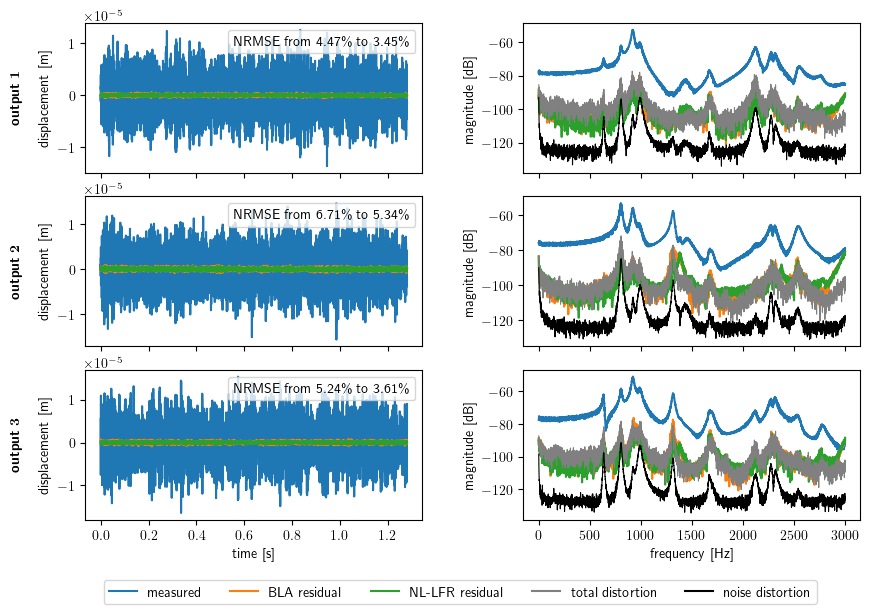

In [ ]:
bla_300mV = fss.load_model(f"models/bla_300mV.zip")
u_test_300mV = data_test[2].u
y_test_300mV = data_test[2].y

y_test_bla = bla_300mV.simulate(u_test_300mV, offset=1000)[0]
y_test_nllfr = nllfr.simulate(u_test_300mV, offset=1000)[0]
error_bla = y_test_300mV - y_test_bla
error_nllfr = y_test_300mV - y_test_nllfr

# The following four lines are merely to load nonparametric distortion levels from the training data which are useful for plotting
_data = fss.create_data_object(u_train_300mV, y_train_300mV, f_idx, fs)
U_abs = np.abs(_data.freq.U[f_idx]).mean(axis=2, keepdims=True)
std_tot = _data.norm.y_std * np.sqrt(_data.freq.G_bla.var_tot) @ U_abs
std_noise = _data.norm.y_std * np.sqrt(_data.freq.G_bla.var_noise) @ U_abs

# Frequency-domain quantities
Y_test = np.fft.rfft(y_test_300mV, axis=0)[f_idx, :]
Y_error_bla = np.fft.rfft(error_bla, axis=0)[f_idx, :]
Y_error_nllfr = np.fft.rfft(error_nllfr, axis=0)[f_idx, :]

Y_test_abs = np.mean(np.abs(Y_test), axis=(2, 3))
Y_error_bla_abs = np.mean(np.abs(Y_error_bla), axis=(2, 3))
Y_error_nllfr_abs = np.mean(np.abs(Y_error_nllfr), axis=(2, 3))

# Compute averaged NRMSE per output channel
norm = np.mean(y_test_300mV**2, axis=(0, 2, 3))
mse_bla = np.mean(error_bla**2, axis=(0, 2, 3))
nrmse_bla = 100 * np.sqrt(mse_bla / norm) 
mse_nllfr = np.mean(error_nllfr**2, axis=(0, 2, 3))
nrmse_nllfr = 100 * np.sqrt(mse_nllfr / norm)

NRMSE_list_bla = 100 * np.sqrt(np.mean(error_bla**2, axis=0) / np.mean(y_test_300mV**2, axis=0))
NRMSE_list_nllfr = 100 * np.sqrt(np.mean(error_nllfr**2, axis=0) / np.mean(y_test_300mV**2, axis=0))

print(f"BLA test error at {test.name}")
for i, val in enumerate(nrmse_bla):
    print(f"    Output {i+1}: {val:.2f}%")
print()

print(f"NL-LFR test error at {test.name}")
for i, val in enumerate(nrmse_nllfr):
    print(f"    Output {i+1}: {val:.2f}%")
    

# Plot results
rcParams['text.usetex'] = True

fig = plt.figure(figsize=(10, 7))
gs = gridspec.GridSpec(4, 2, height_ratios=[2, 2, 2, .25], hspace=0.2, wspace=0.3)
axs_mag = []
for i in range(3):
    # Time-domain plots
    ax_time = fig.add_subplot(gs[i, 0])
    ax_time.plot(data.time.t, y_test_300mV[:, i, 0, 0])
    ax_time.plot(data.time.t, error_bla[:, i, 0, 0])
    ax_time.plot(data.time.t, error_nllfr[:, i, 0, 0])
    if i < 2:
        ax_time.set_xticklabels([])
    else:
        ax_time.set_xlabel("time [s]")
    ax_time.set_ylabel(rf"$\textbf{{output }} \mathbf{{{i+1}}}$" + "\n\n" + r"displacement [m]")

    # NRMSE legend
    nrmse_text = Line2D(
        [], [], linestyle='None', marker='', 
        label=f'NRMSE from {NRMSE_list_bla[i, 0, 0]:.2f}\% to {NRMSE_list_nllfr[i, 0, 0]:.2f}\%'
    )
    ax_time.legend(handles=[nrmse_text], loc='upper right', frameon=True, 
                   handlelength=0, handletextpad=0)

    # Frequency-domain plots
    ax_mag = fig.add_subplot(gs[i, 1])
    ax_mag.plot(data.freq.f[data.freq.f_idx], 20*np.log10(Y_test_abs[:, i]))
    ax_mag.plot(data.freq.f[data.freq.f_idx], 20*np.log10(Y_error_bla_abs[:, i]))
    ax_mag.plot(data.freq.f[data.freq.f_idx], 20*np.log10(Y_error_nllfr_abs[:, i]))
    ax_mag.plot(data.freq.f[data.freq.f_idx], 20*np.log10(std_tot[:, i]), 
                color='grey', linewidth=0.8)
    ax_mag.plot(data.freq.f[data.freq.f_idx], 20*np.log10(std_noise[:, i]), 
                color='black', linewidth=0.8)
    if i < 2:
        ax_mag.set_xticklabels([])
    else:
        ax_mag.set_xlabel("frequency [Hz]")
    ax_mag.set_ylabel("magnitude [dB]")
    axs_mag.append(ax_mag)

# Legend and layout
ax_legend = fig.add_subplot(gs[3, :])
ax_legend.axis('off')
fig.align_ylabels(axs_mag)

main_legend = [
    Line2D([0], [0], label='measured'),
    Line2D([0], [0], color='C1', label='BLA residual'),
    Line2D([0], [0], color='C2', label='NL-LFR residual'),
    Line2D([0], [0], color='grey', label='total distortion'),
    Line2D([0], [0], color='black', label='noise distortion'),
]

fig.legend(handles=main_legend, loc='lower center', ncol=5, frameon=True,
           borderaxespad=0.0, bbox_to_anchor=(0.5, 0.05))

plt.savefig("../docs/imgs/nllfr_vs_bla_300mV.pdf", dpi=300, bbox_inches='tight')
plt.savefig("../docs/imgs/nllfr_vs_bla_300mV.png", dpi=300, bbox_inches='tight')
plt.show()

The performance improvement of the NL-LFR model over the BLA model is modest.
At the same time, the gap between the NL-LFR residual and the noise floor
indicates that significant improvement remains possible.
Note however that the NL-LFR model achieves consistent performance across all amplitude
levels, whereas a single BLA model cannot. For further details, see
`analyze_models.ipynb`.